# Step 2a — Basic swap test in Qiskit

Goal: build the minimal swap-test circuit (ancilla + test qubit + one training qubit, no index/label registers), and check that the fidelity it gives matches `fidelity()` from `closed_form_kernel.py` (Step 1) for the same pair of states.

This is the circuit-building equivalent of Eq. (8)/(9) for a single training point (M=1), n=1.

In [1]:
import numpy as np

from closed_form_kernel import training_data, test_state, fidelity
from circuit_kernel import swap_test_circuit, fidelity_from_circuit

## Sanity check: inspect the circuit

Before trusting any numbers, draw the circuit and make sure it visually matches what you intended: H, controlled-SWAP, H, with the two states initialized on the right qubits.

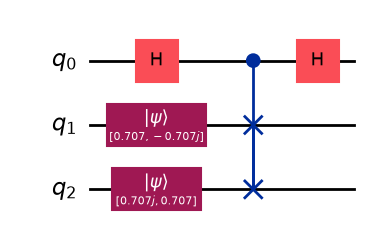

In [2]:
x1, y1, x2, y2 = training_data()
theta = 1.57

qc = swap_test_circuit(test_state(theta), x1)
qc.draw('mpl')

## Single-point check

Compare `fidelity_from_circuit` against `fidelity` from Step 1, at the same theta you hand-checked earlier (theta = 1.57).

In [3]:
circuit_fid = fidelity_from_circuit(test_state(theta), x1)
closed_form_fid = fidelity(test_state(theta), x1)

print('circuit    :', circuit_fid)
print('closed-form:', closed_form_fid)

assert np.isclose(circuit_fid, closed_form_fid), "circuit and closed-form fidelity disagree"

circuit    : 0.9999998414659164
closed-form: 0.9999998414659174


## Full theta sweep, against x1 and against x2

Once the single point matches, sweep theta and check the *whole curve* against the closed-form fidelity, for both training states. This is a much stronger check than one point -- it would catch e.g. a sign error that only shows up for some thetas.

In [4]:
thetas = np.linspace(0, 6, num=40)  # keep small while debugging -- each point runs a circuit

circuit_fid_x1 = np.array([fidelity_from_circuit(test_state(t), x1) for t in thetas])
closed_fid_x1  = np.array([fidelity(test_state(t), x1) for t in thetas])

circuit_fid_x2 = np.array([fidelity_from_circuit(test_state(t), x2) for t in thetas])
closed_fid_x2  = np.array([fidelity(test_state(t), x2) for t in thetas])

assert np.allclose(circuit_fid_x1, closed_fid_x1), "mismatch for x1"
assert np.allclose(circuit_fid_x2, closed_fid_x2), "mismatch for x2"
print('Circuit matches closed-form fidelity across the full sweep, for both training states.')

Circuit matches closed-form fidelity across the full sweep, for both training states.


## Next: Step 2b

Once this notebook runs clean, the next step is extending `circuit_kernel.py` to the full toy-example circuit (Fig. 6): add the index qubit (carrying the weights w1, w2) and the label qubit, so the circuit reproduces `expectation_value()` directly -- not just a single fidelity -- exactly as Eq. (9) does.

In [5]:
from circuit_kernel import expectation_value_from_circuit

theta = np.linspace(0, 6, num=40)
fidelities = [expectation_value_from_circuit(t) for t in theta]

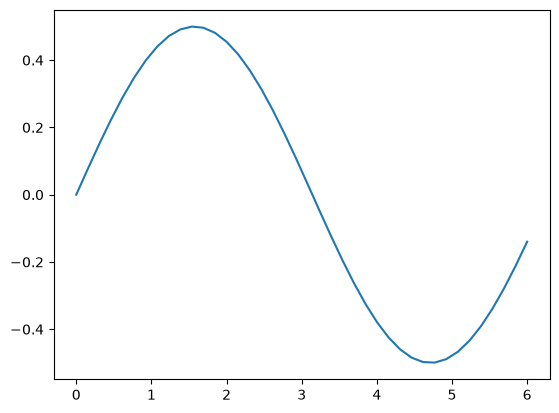

In [6]:
import matplotlib.pyplot as plt
plt.plot(theta, fidelities)

## Step 2b generalisation: quantum forking for M > 2

`prepare_training_register` now implements the general quantum forking circuit (paper Eq. 15 / Fig. 4).  For M training points with k = ⌈log₂ M⌉ index qubits, the circuit:

1. Initialises M data registers to x₁ … x_M.
2. Puts the index register in weighted superposition √w_m|m⟩.
3. Applies M-1 controlled-SWAPs: when index = m, swaps the active data register with auxiliary register m.
4. Encodes labels via controlled-X flips.

Result: √w_m |m⟩_idx |x_m⟩_data |y_m⟩_lbl  (exactly Eq. 9 of the paper).

The M = 2 Z-flip trick is no longer needed: the general circuit reduces correctly to the 2-point case.

Below: verify M = 4 against the closed-form analytic expectation value.

In [7]:
from circuit_kernel import full_classifier_circuit
from closed_form_kernel import test_state, fidelity
from qiskit.quantum_info import Statevector

# Four training states, two classes (y=0: first two, y=1: last two), equal weights
state_thetas = [0.3, 1.1, 2.0, 2.9]
states4  = [np.array([np.cos(t/2), np.sin(t/2)]) for t in state_thetas]
labels4  = [0, 0, 1, 1]
weights4 = [0.25, 0.25, 0.25, 0.25]

def ev_circuit_general(theta_test, states, labels, weights):
    qc, label_q = full_classifier_circuit(test_state(theta_test), states, labels, weights)
    sv = Statevector.from_instruction(qc)
    p = sv.probabilities([0, label_q])
    return p[0] - p[1] - p[2] + p[3]

def ev_analytic(theta_test, states, labels, weights):
    phi = test_state(theta_test)
    return sum(w * (-1)**y * fidelity(phi, x) for x, y, w in zip(states, labels, weights))

thetas_sweep = np.linspace(0, 6, num=40)
circ4     = np.array([ev_circuit_general(t, states4, labels4, weights4) for t in thetas_sweep])
analytic4 = np.array([ev_analytic(t, states4, labels4, weights4)        for t in thetas_sweep])

assert np.allclose(circ4, analytic4), f"M=4 mismatch: max err = {np.max(np.abs(circ4 - analytic4)):.2e}"
print(f"M=4 circuit matches analytic formula. Max error: {np.max(np.abs(circ4 - analytic4)):.2e}")

M=4 circuit matches analytic formula. Max error: 1.89e-15


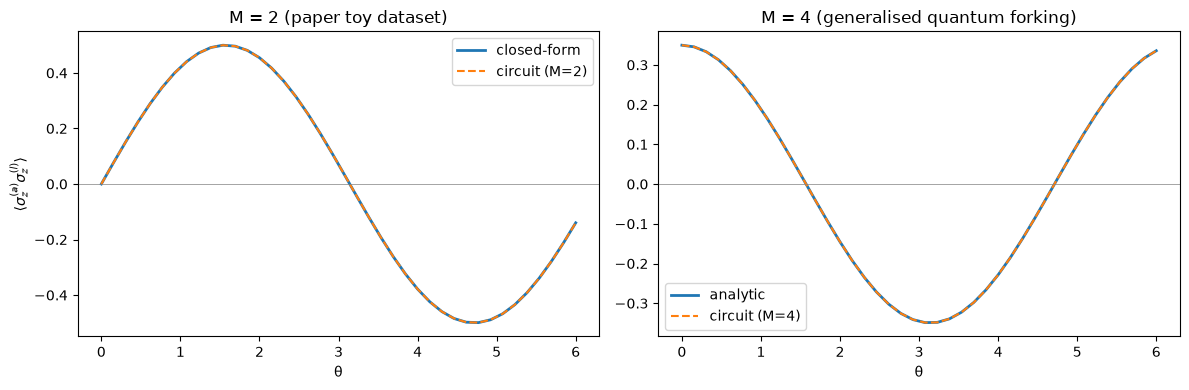

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# M=2 (toy dataset from paper)
thetas_m2 = np.linspace(0, 6, num=40)
circ_m2    = np.array([expectation_value_from_circuit(t) for t in thetas_m2])
from closed_form_kernel import expectation_value as ev_cf
cf_m2 = np.array([ev_cf(t) for t in thetas_m2])
axes[0].plot(thetas_m2, cf_m2,   label='closed-form', lw=2)
axes[0].plot(thetas_m2, circ_m2, '--', label='circuit (M=2)', lw=1.5)
axes[0].axhline(0, color='gray', lw=0.5)
axes[0].set_title('M = 2 (paper toy dataset)')
axes[0].set_xlabel('θ')
axes[0].set_ylabel(r'$\langle\sigma_z^{(a)}\sigma_z^{(l)}\rangle$')
axes[0].legend()

# M=4
axes[1].plot(thetas_sweep, analytic4, label='analytic',       lw=2)
axes[1].plot(thetas_sweep, circ4,    '--', label='circuit (M=4)', lw=1.5)
axes[1].axhline(0, color='gray', lw=0.5)
axes[1].set_title('M = 4 (generalised quantum forking)')
axes[1].set_xlabel('θ')
axes[1].legend()

plt.tight_layout()
plt.show()